• DOMAIN: Smartphone, Electronics

• CONTEXT: India is the second largest market globally for smartphones after China. About 134 million smartphones were sold across India
in the year 2017 and is estimated to increase to about 442 million in 2022. India ranked second in the average time spent on mobile web by
smartphone users across Asia Pacific. The combination of very high sales volumes and the average smartphone consumer behaviour has
made India a very attractive market for foreign vendors. As per Consumer behaviour, 97% of consumers turn to a search engine when they
are buying a product vs. 15% who turn to social media. If a seller succeeds to publish smartphones based on user’s behaviour/choice at the
right place, there are 90% chances that user will enquire for the same. This Case Study is targeted to build a recommendation system
based on individual consumer’s behaviour or choice.

• DATA DESCRIPTION:
• author : name of the person who gave the rating
• country : country the person who gave the rating belongs to
• data : date of the rating
• domain: website from which the rating was taken from
• extract: rating content
• language: language in which the rating was given
• product: name of the product/mobile phone for which the rating was given
• score: average rating for the phone
• score_max: highest rating given for the phone
• source: source from where the rating was taken

*Data source:

• PROJECT OBJECTIVE: We will build a recommendation system using popularity based and collaborative filtering methods to recommend
mobile phones to a user which are most popular and personalised respectively..

Steps and tasks: [ Total Score: 60 points]

1. Import the necessary libraries and read the provided CSVs as a data frame and perform the below steps.

• Merge the provided csvs into one dataframe

• Check a few observations and shape of the dataframe

• Round off scores to the nearest integers

• Check for missing values. Impute the missing values if there is any

• Check for duplicate values and remove them if there is any

• Keep only 1000000 data samples. Use random state=612

• Drop irrelevant features. Keep features like Author, Product, and Score

2. Answer the following questions

• Identify the most rated features
• Identify the users with most number of reviews
• Select the data with products having more than 50 ratings and users who have given more than 50 ratings. Report the shape of the final
dataset.
3. Build a popularity based model and recommend top 5 mobile phones
4. Build a collaborative filtering model using SVD. You can use SVD from surprise or build it from scratch(Note: Incase you’re building it from scratch you
can limit your data points to 10000 samples if you face memory issues). ( 5 points)
5. Build a collaborative filtering model using kNNWithMeans from surprise. You can try both user-based and item-based model ( 5 points)
6. Evaluate the collaborative model. Print RMSE value. ( 2.5 points)
7. Predict score (average rating) for test users. ( 2.5 points)
8. Report your findings and inferences ( 5 points)
9. Try and recommend top 5 products for test users. ( 5 points)
10. Check for outliers and impute them as required. Program co-ordinator confirmed to ignore this question.
11. Try cross validation techniques to get better results.
12. In what business scenario you should use popularity based Recommendation Systems?
13. In what business scenario you should use CF based Recommendation Systems?
14. What other possible methods can you think of which can further improve the recommendation for different users?

In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
import os
os.chdir('/content/drive/MyDrive/RS/External Assessment')
os.getcwd()

'/content/drive/MyDrive/RS/External Assessment'

In [76]:
#import Libraries

#importing ploting libraries
%matplotlib inline
import matplotlib.pyplot as plt 

#For numerical libraries
import numpy as np

#To handle data in the form of rows and columns
import pandas as pd

#importing seaborn for statistical plots
import seaborn as sns

from os import chdir
from glob import glob

from sklearn.impute import SimpleImputer

In [77]:
df_phone_user1=pd.read_csv('phone_user_review_file_1.csv', error_bad_lines=False, encoding="latin-1")
print('Shape of user review file 1:', df_phone_user1.shape)

Shape of user review file 1: (374910, 11)


In [79]:
df_phone_user2=pd.read_csv('phone_user_review_file_2.csv', error_bad_lines=False, encoding="latin-1")
print('Shape of user review file 2:', df_phone_user2.shape)

Shape of user review file 2: (114925, 11)


In [80]:
df_phone_user3=pd.read_csv('phone_user_review_file_3.csv', error_bad_lines=False, encoding="latin-1")
print('Shape of user review file 3:', df_phone_user3.shape)

Shape of user review file 3: (312961, 11)


In [81]:
df_phone_user4=pd.read_csv('phone_user_review_file_4.csv', error_bad_lines=False, encoding="latin-1")
print('Shape of user review file 4:', df_phone_user4.shape)

Shape of user review file 4: (98284, 11)


In [82]:
df_phone_user5=pd.read_csv('phone_user_review_file_5.csv', error_bad_lines=False, encoding="latin-1")
print('Shape of user review file 5:', df_phone_user5.shape)

Shape of user review file 5: (350216, 11)


In [84]:
df_phone_user6=pd.read_csv('phone_user_review_file_6.csv', error_bad_lines=False, encoding="latin-1")
print('Shape of user review file 6:', df_phone_user6.shape)

Shape of user review file 6: (163837, 11)


In [85]:
df_phone_user6.dtypes

phone_url     object
date          object
lang          object
country       object
source        object
domain        object
score        float64
score_max    float64
extract       object
author        object
product       object
dtype: object

1.a - Merge the provided csvs into one dataframe

In [86]:
path = "/content/drive/MyDrive/RS/External Assessment"
allFiles = glob(os.path.join(path,"*.csv"))

li = []
for file_ in allFiles:
  df = pd.read_csv(file_, index_col=None, header='infer',error_bad_lines=False, encoding="latin-1")
  li.append(df)
big_frame = pd.concat(li, axis=0)
big_frame.to_csv('/content/drive/MyDrive/RS/External Assessment/df_phone.csv', index=False)

In [87]:
print(df.shape)

(163837, 11)


In [88]:
df_phone=pd.read_csv('df_phone.csv')

1.b - Check a few observations and shape of the dataframe

In [89]:
print("shape of consolidated dataframe:", df_phone.shape)

shape of consolidated dataframe: (1415133, 11)


In [90]:
df_phone.columns

Index(['phone_url', 'date', 'lang', 'country', 'source', 'domain', 'score',
       'score_max', 'extract', 'author', 'product'],
      dtype='object')

In [91]:
df_phone.dtypes

phone_url     object
date          object
lang          object
country       object
source        object
domain        object
score        float64
score_max    float64
extract       object
author        object
product       object
dtype: object

In [93]:
df_phone.describe().T

,count,mean,std,min,25%,50%,75%,max
score,1351644.0,8.00706,2.616121,0.2,7.2,9.2,10.0,10.0
score_max,1351644.0,10.00000,0.000000,10.0,10.0,10.0,10.0,10.0


In [94]:
df_phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1415133 entries, 0 to 1415132
Data columns (total 11 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   phone_url  1415133 non-null  object 
 1   date       1415133 non-null  object 
 2   lang       1415133 non-null  object 
 3   country    1415133 non-null  object 
 4   source     1415133 non-null  object 
 5   domain     1415133 non-null  object 
 6   score      1351644 non-null  float64
 7   score_max  1351644 non-null  float64
 8   extract    1395772 non-null  object 
 9   author     1351931 non-null  object 
 10  product    1415132 non-null  object 
dtypes: float64(2), object(9)
memory usage: 118.8+ MB


In [95]:
#look at data in the consolidated / merge dataset
df_phone.head(5)

,phone_url,date,lang,country,source,domain,score,score_max,extract,author,product
0,/cellphones/samsung-galaxy-s8/,5/2/2017,en,us,Verizon Wireless,verizonwireless.com,10.0,10.0,As a diehard Samsung fan who has had every Sam...,CarolAnn35,Samsung Galaxy S8
1,/cellphones/samsung-galaxy-s8/,4/28/2017,en,us,Phone Arena,phonearena.com,10.0,10.0,Love the phone. the phone is sleek and smooth ...,james0923,Samsung Galaxy S8
2,/cellphones/samsung-galaxy-s8/,5/4/2017,en,us,Amazon,amazon.com,6.0,10.0,Adequate feel. Nice heft. Processor's still sl...,R. Craig,"Samsung Galaxy S8 (64GB) G950U 5.8"" 4G LTE Unl..."
3,/cellphones/samsung-galaxy-s8/,5/2/2017,en,us,Samsung,samsung.com,9.2,10.0,Never disappointed. One of the reasons I've be...,Buster2020,Samsung Galaxy S8 64GB (AT&T)
4,/cellphones/samsung-galaxy-s8/,5/11/2017,en,us,Verizon Wireless,verizonwireless.com,4.0,10.0,I've now found that i'm in a group of people t...,S Ate Mine,Samsung Galaxy S8


1.c - Round off scores to the nearest integers

In [96]:
df_phone['score']= round(df_phone['score'])

In [97]:
df_phone.head(5)

,phone_url,date,lang,country,source,domain,score,score_max,extract,author,product
0,/cellphones/samsung-galaxy-s8/,5/2/2017,en,us,Verizon Wireless,verizonwireless.com,10.0,10.0,As a diehard Samsung fan who has had every Sam...,CarolAnn35,Samsung Galaxy S8
1,/cellphones/samsung-galaxy-s8/,4/28/2017,en,us,Phone Arena,phonearena.com,10.0,10.0,Love the phone. the phone is sleek and smooth ...,james0923,Samsung Galaxy S8
2,/cellphones/samsung-galaxy-s8/,5/4/2017,en,us,Amazon,amazon.com,6.0,10.0,Adequate feel. Nice heft. Processor's still sl...,R. Craig,"Samsung Galaxy S8 (64GB) G950U 5.8"" 4G LTE Unl..."
3,/cellphones/samsung-galaxy-s8/,5/2/2017,en,us,Samsung,samsung.com,9.0,10.0,Never disappointed. One of the reasons I've be...,Buster2020,Samsung Galaxy S8 64GB (AT&T)
4,/cellphones/samsung-galaxy-s8/,5/11/2017,en,us,Verizon Wireless,verizonwireless.com,4.0,10.0,I've now found that i'm in a group of people t...,S Ate Mine,Samsung Galaxy S8


 1.d - Check for missing values. Impute the missing values if there is any

In [98]:
#Look for missing values
df_phone.isnull().sum()

phone_url        0
date             0
lang             0
country          0
source           0
domain           0
score        63489
score_max    63489
extract      19361
author       63202
product          1
dtype: int64

In [99]:
#df_phone['score'] = df_phone['score'].fillna(df_phone.score.mean())
df_phone['score'] = df_phone['score'].fillna(0)
df_phone['score_max'] = df_phone['score_max'].fillna(df_phone.score_max.mean())
df_phone['author']=df_phone['author'].fillna(df_phone['author'].mode()[0])
df_phone['extract']=df_phone['extract'].fillna(df_phone['extract'].mode()[0])
df_phone['product']=df_phone['product'].fillna(df_phone['product'].mode()[0])

1.e - Check for duplicate values and remove them if there is any

In [100]:
##Identify duplicates records in the data
dupes = df_phone.duplicated()
sum(dupes)

6436

In [101]:
df_phone.drop_duplicates(keep='first', inplace=True)

In [102]:
df_phone.shape

(1408697, 11)

In [103]:
df_phone.nunique()

phone_url       5556
date            7728
lang              22
country           42
source           331
domain           384
score             11
score_max          1
extract      1321353
author        801103
product        61313
dtype: int64

1.f - Keep only 1000000 data samples. Use random state=612

In [165]:
df_final=df_phone.sample(n=1000000, random_state=612)

In [166]:
df_final.shape

(1000000, 11)

In [167]:
df_final.columns

Index(['phone_url', 'date', 'lang', 'country', 'source', 'domain', 'score',
       'score_max', 'extract', 'author', 'product'],
      dtype='object')

1.g - Drop irrelevant features. Keep features like Author, Product, and Score

In [168]:
df_final.drop(['phone_url', 'date', 'lang', 'country', 'source', 'domain','score_max', 'extract'], axis=1, inplace=True)

In [109]:
print("Columns in Final dataframe:", df_final.columns)
print("Shape of final Dataframe:", df_final.shape)

Columns in Final dataframe: Index(['score', 'author', 'product'], dtype='object')
Shape of final Dataframe: (1000000, 3)


2. Answer the following questions

2.1 - Identify the most rated features

In [110]:
#calculate number of times author have rated a Product. 
most_rated_prod=df_final.groupby(by=['product','score', 'author']).size().reset_index(name="Rating_count").sort_values(by=['score', 'Rating_count', 'author'],ascending=False)

most_rated_prod.head(10)

,product,score,author,Rating_count
506607,"OnePlus 3 (Graphite, 64 GB)",10.0,Amazon Customer,830
508146,"OnePlus 3 (Soft Gold, 64 GB)",10.0,Amazon Customer,752
321242,"Lenovo Vibe K4 Note (White,16GB)",10.0,Amazon Customer,747
319813,"Lenovo Vibe K4 Note (Black, 16GB)",10.0,Amazon Customer,602
509506,"OnePlus 3T (Gunmetal, 6GB RAM + 64GB memory)",10.0,Amazon Customer,383
684459,"Samsung Galaxy S7 edge Smartphone, 13,9 cm (5,...",10.0,einer Kundin,329
322315,"Lenovo Vibe K5 (Gold, VoLTE update)",10.0,Amazon Customer,286
323224,"Lenovo Vibe K5 (Grey, VoLTE update)",10.0,Amazon Customer,265
510143,"OnePlus 3T (Soft Gold, 6GB RAM + 64GB memory)",10.0,Amazon Customer,259
684458,"Samsung Galaxy S7 edge Smartphone, 13,9 cm (5,...",10.0,einem Kunden,258


2.2 - Identify the users with most number of reviews

In [111]:
author_reviews= df_final.groupby(['author', 'score']).size().sort_values(ascending=False).reset_index(name="Review_count")
#author_reviews=df_final.groupby(by='author')['score'].count().sort_values(ascending=False)
author_reviews.head(10)

,author,score,Review_count
0,Amazon Customer,10.0,42796
1,Amazon Customer,8.0,20650
2,Amazon Customer,2.0,15020
3,Amazon Customer,6.0,9984
4,Cliente Amazon,10.0,7095
5,Amazon Customer,4.0,6854
6,e-bit,10.0,3566
7,Cliente Amazon,8.0,3268
8,Client d'Amazon,10.0,2236
9,Amazon Customer,0.0,1846


2.3 - Select the data with products having more than 50 ratings and users who have given more than 50 ratings. Report the shape of the final dataset.

In [112]:
#products having more than 50 ratings - 562819 rows × 3 columns

top50_prd_ct = df_final.groupby(['product']).filter(lambda x: len(x) >=50) 

#users who have given more than 50 ratings -118633 rows × 3 columns
top50_author_ct= df_final.groupby(['author']).filter(lambda x: len(x) >=50)


#Total 681,452 rows
#df_final_new=top50_prd_ct.append(top50_author_ct)


In [113]:
author_ct=top50_prd_ct['author'].value_counts()
df_final_new1=top50_prd_ct[top50_prd_ct['author'].isin(author_ct[author_ct>=50].index)]
df_final_new1.shape

(118633, 3)

In [114]:
df_final_new1.head(10)

,score,author,product
230845,8.0,Cliente Amazon,"Microsoft Telefonia Lumia 950 XL Smartphone, 3..."
1150123,10.0,Amazon Customer,Samsung C5212
1171786,10.0,Amazon Customer,Nokia E52
505343,2.0,Amazon Customer,Nokia Lumia 635 8GB Unlocked GSM 4G LTE Window...
766631,2.0,Amazon Customer,"Lenovo Used Lenovo Zuk Z1 (Space Grey, 64GB)"
1244089,10.0,Anonymous,Samsung Rant
119096,10.0,Amazon Customer,"OnePlus 3T (Gunmetal, 6GB RAM + 64GB memory)"
1246639,8.0,Anonymous,LG enV3
102400,6.0,Amazon Customer,Samsung Galaxy S6 G920F 32GB Factory Unlocked ...
567748,4.0,Amazon Customer,Blu Win HD LTE (Grey)


3. Build a popularity based model and recommend top 5 mobile phones

In [115]:
prod_mean=pd.DataFrame(df_final_new1.groupby('product')['score'].mean())
prod_mean['score_count']=pd.DataFrame(df_final_new1.groupby('product')['score'].count())
prod_mean['topscore'] = pd.DataFrame(prod_mean['score']*prod_mean['score_count'])

#ratings_mean_count = pd.DataFrame(new_df.groupby('productId')['Rating'].mean())
#ratings_mean_count['rating_counts'] = pd.DataFrame(new_df.groupby('productId')['Rating'].count())

In [116]:
prod_mean.sort_values(by='topscore', ascending=False).head()

,score,score_count,topscore
product,,,
"Lenovo Vibe K4 Note (White,16GB)",6.981184,2179,15212.0
"Lenovo Vibe K4 Note (Black, 16GB)",7.052751,1763,12434.0
"OnePlus 3 (Graphite, 64 GB)",8.530046,1298,11072.0
"OnePlus 3 (Soft Gold, 64 GB)",8.322900,1214,10104.0
"Lenovo Vibe K5 (Gold, VoLTE update)",6.560290,1103,7236.0


4. Build a collaborative filtering model using SVD. You can use SVD from surprise or build it from scratch(Note: Incase you’re building it from scratch you
can limit your data points to 10000 samples if you face memory issues).

In [117]:
!pip install surprise

In [119]:
from surprise import Dataset, Reader
from surprise.model_selection import cross_validate
from surprise import NormalPredictor
from surprise import SVD
from surprise import accuracy
from surprise import KNNWithMeans


In [120]:
df_final_new1.columns

Index(['score', 'author', 'product'], dtype='object')

In [121]:
reader = Reader(rating_scale=(0.2, 10))
surprise_data=Dataset.load_from_df(df_final_new1[['author', 'product','score']], reader)

In [122]:
type(surprise_data)

surprise.dataset.DatasetAutoFolds

In [123]:
# Split data to train and test
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(surprise_data, test_size=.25,random_state=12)

In [124]:
svd_model = SVD(n_factors=30, n_epochs =20, lr_all=0.001, random_state=12)
svd_model.fit(trainset)

In [125]:
#Evaluate on test set
svd_test_pred = svd_model.test(testset)

In [126]:
svd_test_pred

[Prediction(uid='Amazon Customer', iid='Samsung Galaxy J7 SM-J700F (White) - Scheduled/4 Hour Delivery (Brand Fulfilled)', r_ui=10.0, est=7.384705195151852, details={'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='Asus ZenFone 3 Laser 5.5-inch Glacier Silver [ZC551KL] Laser auto-focus, 13MP Rear / 8MP Front camera, IPS FHD display, 2GB RAM, 32GB storage', r_ui=8.0, est=7.389220580644268, details={'was_impossible': False}),
 Prediction(uid='john', iid='Samsung Note 4 Standard Li-ion Battery 3220mAh for Galaxy Note 4 - Non-Retail Packaging', r_ui=6.0, est=7.368299496885606, details={'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='Siemens C55', r_ui=10.0, est=7.696841622465399, details={'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='Nokia E51', r_ui=8.0, est=8.496327942607103, details={'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='Huawei W1 Stainless Steel Classic Smartwatch with Leather Strap [Energy Class A++

In [128]:
svd_test_pred_df = pd.DataFrame([[x.uid,x.iid,x.est] for x in svd_test_pred], columns=['author','product', 'est_score'])

In [129]:
svd_test_pred_df.head()

,author,product,est_score
0,Amazon Customer,Samsung Galaxy J7 SM-J700F (White) - Scheduled...,7.384705
1,Amazon Customer,Asus ZenFone 3 Laser 5.5-inch Glacier Silver [...,7.389221
2,john,Samsung Note 4 Standard Li-ion Battery 3220mAh...,7.368299
3,Amazon Customer,Siemens C55,7.696842
4,Amazon Customer,Nokia E51,8.496328


In [130]:
top_10_recos = svd_test_pred_df.groupby("author").head(10).reset_index(drop=True)

In [131]:
top_10_recos.head(10)

,author,product,est_score
0,Amazon Customer,Samsung Galaxy J7 SM-J700F (White) - Scheduled...,7.384705
1,Amazon Customer,Asus ZenFone 3 Laser 5.5-inch Glacier Silver [...,7.389221
2,john,Samsung Note 4 Standard Li-ion Battery 3220mAh...,7.368299
3,Amazon Customer,Siemens C55,7.696842
4,Amazon Customer,Nokia E51,8.496328
5,Amazon Customer,Huawei W1 Stainless Steel Classic Smartwatch w...,8.756773
6,Amazon Customer,"Apple iPhone 5 Cellphone, 16GB, Black (AT&T)",6.241077
7,Amazon Customer,"OnePlus 3T (Gunmetal, 6GB RAM + 64GB memory)",8.385044
8,ÐÐ½ÑÐ¾Ð½,Apple iPhone 5s 16GB (ÑÐµÑÐµÐ±ÑÐ¸ÑÑÑÐ¹),8.761883
9,Amazon Customer,"Lenovo PHAB Plus Tablet (6.8 inch, 32GB, Wi-Fi...",7.238737


In [132]:
# compute RMSE
rmse_svd=accuracy.rmse(svd_test_pred)
rmse_svd

RMSE: 2.7175


2.717472291027096

5. Build a collaborative filtering model using kNNWithMeans from surprise. You can try both user-based and item-based model ( 5 points)

5.1 - User Based Model

In [133]:
userbased_alg = KNNWithMeans(k=51, sim_options={'name': 'cosine', 'user_based': True})
userbased_alg.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


/usr/local/lib/python3.7/dist-packages/surprise/prediction_algorithms/algo_base.py:249: RuntimeWarning: invalid value encountered in double_scalars
  sim = construction_func[name](*args)


In [134]:
# Evalute on test set
UBCF_test_pred = userbased_alg.test(testset)

In [135]:
UBCF_test_pred

[Prediction(uid='Amazon Customer', iid='Samsung Galaxy J7 SM-J700F (White) - Scheduled/4 Hour Delivery (Brand Fulfilled)', r_ui=10.0, est=7.3076923076923075, details={'actual_k': 26, 'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='Asus ZenFone 3 Laser 5.5-inch Glacier Silver [ZC551KL] Laser auto-focus, 13MP Rear / 8MP Front camera, IPS FHD display, 2GB RAM, 32GB storage', r_ui=8.0, est=7.309320362072593, details={'actual_k': 35, 'was_impossible': False}),
 Prediction(uid='john', iid='Samsung Note 4 Standard Li-ion Battery 3220mAh for Galaxy Note 4 - Non-Retail Packaging', r_ui=6.0, est=6.563397599212301, details={'actual_k': 34, 'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='Siemens C55', r_ui=10.0, est=6.005574524333218, details={'actual_k': 6, 'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='Nokia E51', r_ui=8.0, est=8.43137254901961, details={'actual_k': 51, 'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='Hu

In [138]:
# compute RMSE
rmse_UBCF = accuracy.rmse(UBCF_test_pred)
rmse_UBCF

RMSE: 2.7457


2.745673335564414

In [140]:
# View a particular prediction
UBCF_test_pred[10]

Prediction(uid='Amazon Customer', iid='Nokia 7500 Prism', r_ui=8.0, est=7.444444444444445, details={'actual_k': 18, 'was_impossible': False})

In [141]:
# convert results to dataframe
UBCF_test_pred_df = pd.DataFrame(UBCF_test_pred)
UBCF_test_pred_df["was_impossible"] = [x["was_impossible"] for x in UBCF_test_pred_df["details"]]

In [142]:
UBCF_test_pred_df.loc[UBCF_test_pred_df.was_impossible].tail(5)

,uid,iid,r_ui,est,details,was_impossible
27924,Cliente de Amazon,Samsung Galaxy Y S5360 - Smartphone libre Andr...,10.0,7.568514,"{'was_impossible': True, 'reason': 'User and/o...",True
28449,Christian,"Doro PhoneEasy 610gsm Mobiltelefon (UKW, Bluet...",8.0,7.568514,"{'was_impossible': True, 'reason': 'User and/o...",True
28482,Joe,Sony Xperia Tipo Dual-SIM ST21A2 Unlocked Andr...,2.0,7.568514,"{'was_impossible': True, 'reason': 'User and/o...",True
28487,Un anonyme,Samsung GT-B3410,8.0,7.568514,"{'was_impossible': True, 'reason': 'User and/o...",True
28660,Amazon Customer,HTC Desire S Sim Free Mobile Phone,10.0,7.568514,"{'was_impossible': True, 'reason': 'User and/o...",True


In [143]:
# Make prediction for a single user
userbased_alg.predict(uid="Amazon Customer",iid="Nokia 7500 Prism")

Prediction(uid='Amazon Customer', iid='Nokia 7500 Prism', r_ui=None, est=7.444444444444445, details={'actual_k': 18, 'was_impossible': False})

5.2 - Item based Model

In [144]:
itembased_alg = KNNWithMeans(k=51, sim_options={'name': 'cosine', 'user_based': False})
itembased_alg.fit(trainset)

Computing the cosine similarity matrix...


/usr/local/lib/python3.7/dist-packages/surprise/prediction_algorithms/algo_base.py:249: RuntimeWarning: invalid value encountered in double_scalars
  sim = construction_func[name](*args)


Done computing similarity matrix.


In [145]:
# Evalute on test set
IBCF_test_pred = itembased_alg.test(testset)

In [146]:
IBCF_test_pred

[Prediction(uid='Amazon Customer', iid='Samsung Galaxy J7 SM-J700F (White) - Scheduled/4 Hour Delivery (Brand Fulfilled)', r_ui=10.0, est=7.803117528602167, details={'actual_k': 51, 'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='Asus ZenFone 3 Laser 5.5-inch Glacier Silver [ZC551KL] Laser auto-focus, 13MP Rear / 8MP Front camera, IPS FHD display, 2GB RAM, 32GB storage', r_ui=8.0, est=7.433109506106893, details={'actual_k': 51, 'was_impossible': False}),
 Prediction(uid='john', iid='Samsung Note 4 Standard Li-ion Battery 3220mAh for Galaxy Note 4 - Non-Retail Packaging', r_ui=6.0, est=6.325857165247617, details={'actual_k': 37, 'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='Siemens C55', r_ui=10.0, est=6.500014405144181, details={'actual_k': 51, 'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='Nokia E51', r_ui=8.0, est=8.431372549019608, details={'actual_k': 51, 'was_impossible': False}),
 Prediction(uid='Amazon Customer', iid='H

In [147]:
IBCF_test_pred_df = pd.DataFrame([[x.uid,x.iid,x.est] for x in IBCF_test_pred], columns=['author','product', 'est_score'])
IBCF_test_pred_df

,author,product,est_score
0,Amazon Customer,Samsung Galaxy J7 SM-J700F (White) - Scheduled...,7.803118
1,Amazon Customer,Asus ZenFone 3 Laser 5.5-inch Glacier Silver [...,7.433110
2,john,Samsung Note 4 Standard Li-ion Battery 3220mAh...,6.325857
3,Amazon Customer,Siemens C55,6.500014
4,Amazon Customer,Nokia E51,8.431373
...,...,...,...
29654,ÐÐ¸ÐºÐ¾Ð»Ð°Ð¹,ÐÐ¾Ð±Ð¸Ð»ÑÐ½ÑÐ¹ ÑÐµÐ»ÐµÑÐ¾Ð½ Caterpillar ...,8.431560
29655,Amazon Customer,OnePlus X (Limited Edition Ceramic),6.784314
29656,Amazon Customer,Asus ZenFone 3 Max ZC520TL-4G860IN (Gold),5.200658
29657,Amazon Customer,Nokia Lumia 520,7.882353


In [148]:
# compute RMSE
rmse_IBCF = accuracy.rmse(IBCF_test_pred)
rmse_IBCF

RMSE: 2.7530


2.7529807807020874

6. Evaluate the collaborative model. Print RMSE value. ( 2.5 points)

In [149]:
print("RMSE value of Collaborative Model using SVD: \n", rmse_svd)
print("RMSE value of USER BASED Collaborative Model using SVD: \n", rmse_UBCF)
print("RMSE value of ITEM BASED Collaborative Model using SVD: \n", rmse_IBCF)

RMSE value of Collaborative Model using SVD: 
 2.717472291027096
RMSE value of USER BASED Collaborative Model using SVD: 
 2.745673335564414
RMSE value of ITEM BASED Collaborative Model using SVD: 
 2.7529807807020874


7. Predict score (average rating) for test users. ( 2.5 points)

In [150]:
svd_prediction=np.mean(svd_test_pred_df['est_score'])
print("Prediction score for test user using SVD():", svd_prediction)

Prediction score for test user using SVD(): 7.6144230217332325


In [151]:
UBCF_prediction=np.mean(UBCF_test_pred_df['est'])
print("Prediction score for test user using User Based CF:", UBCF_prediction)

Prediction score for test user using User Based CF: 7.617462522335116


In [152]:
IBCF_prediction=np.mean(IBCF_test_pred_df['est_score'])
print("Prediction score for test user using Item Based CF:", IBCF_prediction)

Prediction score for test user using Item Based CF: 7.643206958936462


8. Report your findings and inferences ( 5 points)

 A user-item filtering takes a particular user, find users that are similar to that user based on similarity of ratings, and recommend items that those similar users liked. In contrast, item-item filtering will take an item, find users who liked that item, and find other items that those users or similar users also liked. It takes items and outputs other items as recommendations.


 Eventhough the RMSE value of all 3 approaches returns same value "7.6", the computational time differs and the approaches are different.

9. Try and recommend top 5 products for test users. ( 5 points)

In [153]:
def recommendation(userID, n):
  testuser_recomm=svd_test_pred_df[svd_test_pred_df['author']==userID][['author','product', 'est_score']].sort_values(by='est_score', ascending=False).head(n)
  return testuser_recomm

In [154]:
recommendation('paolo',5)

,author,product,est_score
11520,paolo,"Lenovo Motorola Moto G Smartphone, 4,5 pollici...",9.591017
20438,paolo,"Huawei P9 Lite Smartphone, LTE, Display 5.2'' ...",9.318839
23414,paolo,"Huawei P9 Lite Smartphone, LTE, Display 5.2'' ...",9.318839
6214,paolo,"Huawei P9 Lite Smartphone, LTE, Display 5.2'' ...",8.883087
25113,paolo,"Asus ZenFone 2 Laser Smartphone, Display da 5""...",8.848519


10. Check for outliers and impute them as required.

In [156]:
ratings=pd.DataFrame(df_final_new1.groupby('product')['score'].mean())
ratings['No_of_Ratings']=pd.DataFrame(df_final_new1.groupby('product')['score'].count())
ratings.head()

,score,No_of_Ratings
product,,
5.5-Inch Unlocked Lenovo A850 3G Smartphone-(960x540) Quad Core 4GB MT6582m 1331MHz Android 4.2 Dual Camera +Dual SIM -Black (Rooted + Google Play),6.000000,4
"AICEK Coque ASUS ZenFone 3 Max ZC520TL, AICEK Etui Silicone Gel ASUS ZenFone 3 Max Housse Antichoc ZenFone 3 Max Transparente Souple Coque de Protection pour ASUS ZenFone 3 Max(5.2 Pouces)",9.529412,17
"AICEK Coque ASUS ZenFone 3 ZE520KL, AICEK Etui Silicone Gel ASUS ZenFone 3 Housse Antichoc ZenFone 3 Transparente Souple Coque de Protection pour ASUS ZenFone 3(5.2 Pouces)",8.600000,20
"AICEK Coque Samsung Galaxy A3 2016, AICEK Etui Silicone Gel Samsung Galaxy A3 2016 (A310F) Housse Antichoc Samsung A3 Transparente Souple Coque De Protection Pour Samsung Galaxy A3 2016 (4,7 pouces)",8.779661,59
"AICEK Coque Samsung Galaxy J3 2016, AICEK Etui Silicone Gel Samsung Galaxy J3 2016 (J320F) Housse Antichoc Samsung J3 Transparente Souple Coque De Protection Pour Samsung Galaxy J3 2016 (5,0 Pouces)",9.047619,21


/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


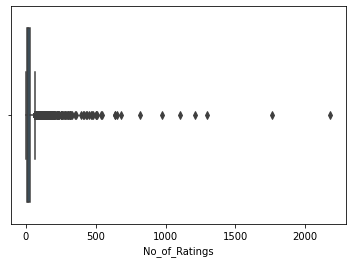

In [157]:
sns.boxplot(ratings['No_of_Ratings'])

In [158]:
#Treat Outliers
def out_iqr(df_final_new1, column):
    global lower,upper
    q25, q75 = np.quantile(df_final_new1[column], 0.25), np.quantile(df_final_new1[column], 0.75)
    # calculate the IQR
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    # calculate the lower and upper bound value
    lower, upper = q25 - cut_off, q75 + cut_off
    print('The IQR is',iqr)
    print('The lower bound value is', lower)
    print('The upper bound value is', upper)
    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df_final_new1[df_final_new1[column] > upper]['No_of_Ratings']
    #df2 = df_final_new1[df_final[column] < lower]
    return print('Total number of outliers are', df1.shape)

In [159]:
out_iqr(ratings,'No_of_Ratings')


The IQR is 23.0
The lower bound value is -28.5
The upper bound value is 63.5
Total number of outliers are (360,)


In [160]:
tmp=ratings[ratings['No_of_Ratings'] > 63.5].sort_values(by='No_of_Ratings', ascending=False)
for i in tmp.index:
   print(i)
   for j in df_final_new1[df_final_new1["product"] == i].sort_values(by="score", ascending=True).index:
      if df_final_new1[df_final_new1["product"] == i].sort_values(by="score", ascending=True)["product"].count() > 63.5:
            df_final_new1.drop(index=j, inplace=True)
      else:
                       break



Lenovo Vibe K4 Note (White,16GB)


/usr/local/lib/python3.7/dist-packages/pandas/core/frame.py:4174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


Lenovo Vibe K4 Note (Black, 16GB)
OnePlus 3 (Graphite, 64 GB)
OnePlus 3 (Soft Gold, 64 GB)
Lenovo Vibe K5 (Gold, VoLTE update)
Lenovo Vibe K5 (Grey, VoLTE update)
Lenovo Used Lenovo Zuk Z1 (Space Grey, 64GB)
Samsung Galaxy S7 edge Smartphone, 13,9 cm (5,5 Zoll) Display, LTE (4G)
Lenovo Vibe K5 (Silver, 16GB)
YU Yuphoria YU5010A (Black+Silver)
OnePlus 3T (Gunmetal, 6GB RAM + 64GB memory)
Motorola Moto G, 4th Gen (Black, 2 GB, 16 GB)
Motorola Moto G Turbo (White, 16GB)
Huawei P9 Lite Smartphone, LTE, Display 5.2'' FHD, Processore Octa-Core Kirin 650, 16 GB Memoria Interna, 3GB RAM, Fotocamera 13 MP, Single-SIM, Android 6.0 Marshmallow, Bianco [Italia]
Apple iPhone 5s (Silver, 16GB)
Lenovo Vibe K5 (Grey)
OnePlus X (Onyx, 16GB)
Asus Zenfone Max ZC550KL-6A068IN (Black, 2GB, 16GB)
Samsung Galaxy S7 Smartphone, 12,9 cm (5,1 Zoll) Display, LTE (4G)
OnePlus 3T (Soft Gold, 6GB RAM + 64GB memory)
Apple iPhone 5s 16GB (ÑÐµÑÐµÐ±ÑÐ¸ÑÑÑÐ¹)
Huawei P8 Lite Smartphone, Display 5" IPS, Processore O

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


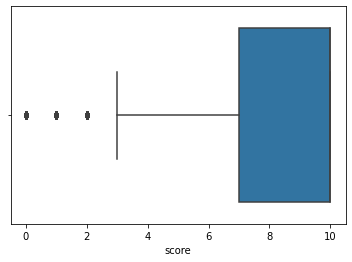

In [161]:
sns.boxplot(df_final_new1['score'])

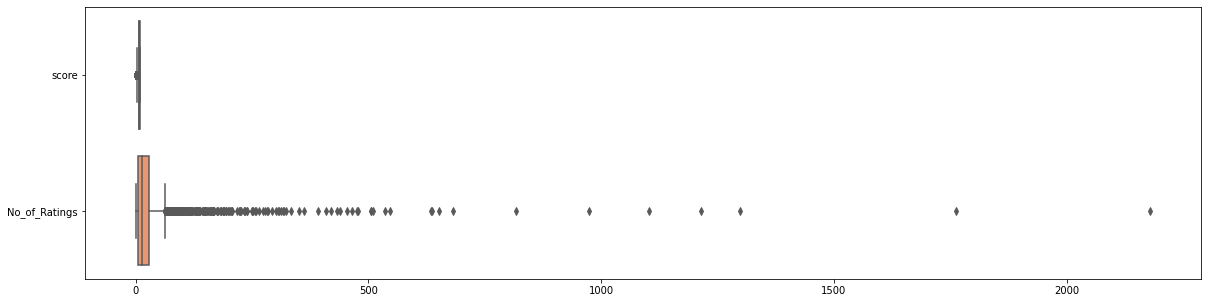

In [162]:
plt.figure(figsize=(20,5))
sns.boxplot(data=ratings, orient='h', palette='Set2', dodge=False)

11. Try cross validation techniques to get better results.

In [163]:
import time
from surprise.model_selection import GridSearchCV
start_time = time.time()

svd_param_grid = {'n_epochs': [20, 25], 'lr_all': [0.007, 0.009, 0.01], 'reg_all': [0.4, 0.6]}

svd_gs = GridSearchCV(SVD, svd_param_grid, measures=['rmse', 'mae'], cv=5, n_jobs=5)

svd_gs.fit(surprise_data)

# best RMSE score
print(svd_gs.best_score['rmse'])

# combination of parameters that gave the best RMSE score
print(svd_gs.best_params['rmse'])

computational_time = time.time() - start_time

print('Done in %0.3fs' %(computational_time))

2.7269238003208756
{'n_epochs': 25, 'lr_all': 0.007, 'reg_all': 0.4}
Done in 448.107s


In [164]:
start_time = time.time()

# Creating Model using best parameters
svd_model = SVD(n_epochs=25, lr_all=0.007, reg_all=0.4)

# Training the algorithm on the trainset
svd_model.fit(trainset)


# Predicting for test set
predictions_svd = svd_model.test(testset)

# Evaluating RMSE, MAE of algorithm SVD on 5 split(s) by cross validation
svd_cv = cross_validate(svd_model, surprise_data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

# Storing Crossvalidation Results in dataframe
svd_df = pd.DataFrame.from_dict(svd_cv)
svd_described = svd_df.describe()
cv_results = pd.DataFrame([['SVD', svd_described['test_rmse']['mean'], svd_described['test_mae']['mean'], 
                           svd_described['fit_time']['mean'], svd_described['test_time']['mean']]],
                            columns = ['Model', 'RMSE', 'MAE', 'Fit Time', 'Test Time'])


# get RMSE
print("\n\n==================== Model Evaluation ===============================")
accuracy.rmse(predictions_svd, verbose=True)
print("=====================================================================")
computational_time = time.time() - start_time
print('\n Computational Time : %0.3fs' %(computational_time))
cv_results

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    2.7114  2.7213  2.7283  2.7311  2.7142  2.7212  0.0077  
MAE (testset)     2.1680  2.1844  2.1839  2.1871  2.2056  2.1858  0.0120  
Fit time          6.90    6.98    6.97    6.98    6.98    6.96    0.03    
Test time         0.18    0.35    0.17    0.18    0.34    0.24    0.09    


==================== Model Evaluation ===============================
RMSE: 2.7057

 Computational Time : 43.957s


,Model,RMSE,MAE,Fit Time,Test Time
0,SVD,2.721234,2.18579,6.960811,0.243571


12. In what business scenario you should use popularity based Recommendation Systems?

It is a type of recommendation system which works on the principle of popularity and or anything which is in trend. These systems check about the product or movie which are in trend or are most popular among the users and directly recommend those.


For example, if a product is often purchased by most people then the system will get to know that that product is most popular so for every new user who just signed it, the system will recommend that product to that user also and chances becomes high that the new user will also purchase that. 

 1. Merits of popularity based recommendation system:
 
  1.1 It does not suffer from cold start problems which means on day 1 of the business also it can recommend products on various different filters.

  1.2 There is no need for the user's historical data.

2. Demerits of popularity based recommendation system
 
  2.1 Not personalized 

  2.2 The system would recommend the same sort of products/movies which are solely based upon popularity to every other user.

 
Example
 
Google News: News filtered by trending and most popular news.

YouTube: Trending videos.

Amazon / Flipcart: Recommend product based on popularity.

Music recommendation - spotify : Recommend based on weekly most rated music.



13. In what business scenario you should use CF based Recommendation Systems?

Collaborative filtering systems make recommendations based on historic users' preference for items (clicked, watched, purchased, liked, rated, etc.). The preference can be presented as a user-item matrix.

This type of recommendation system makes predictions of what might interest a person based on the taste of many other users. It assumes that if person X likes Snickers, and person Y likes Snickers and Milky Way, then person X might like Milky Way as well.


There are 2 types of collaborative Filtering.

a. User-Based Collaborative Filtering
      The system finds out the users who have the same sort of taste of purchasing products and similarity between users is computed based upon the purchase behavior.

b. Item-Based Collaborative Filtering
      The system checks the items that are similar to the items the user bought. The similarity between different items is computed based on the items and not the users for the prediction.

Business scenario:

1. IMDB
2. Amazon Prime video
3. Netflix
4. Youtube
5. Spotify




14. What other possible methods can you think of which can further improve the recommendation for different users?

There are few other methods / recommendation systems available as follows.

1. Content based Filtering

2. Stochastic Gradient Descent (SGD)

3. Classification Model

4. Hybrid Recommendation System

5. Demographic based recommender system:

6. Utility-based recommender system


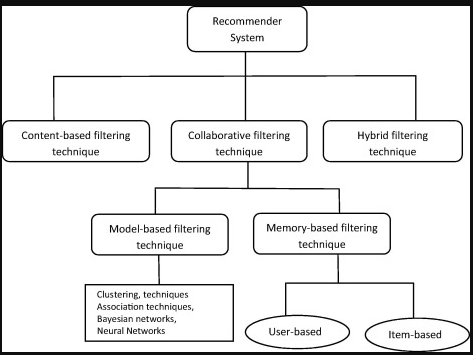